In [ ]:
# Cell 1 — Colab setup: mount Drive and install dependencies
from google.colab import drive
drive.mount('/content/drive')

!pip install -q kornia ultralytics transformers


In [1]:
# Cell 2 — Imports
import cv2
import random
import numpy as np
import torch
import torch.nn.functional as F
import kornia
import kornia.augmentation as K
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

import sys
sys.path.append("..")

from video_segmentation import get_single_mask_from_image, overlay_patch_on_image, load_segformer_model

In [ ]:
# Cell 3 — Config
# ── Training ──────────────────────────────────────────
PATCH_H          = 100
PATCH_W          = 75
PATCH_SCALE      = 0.6    # was 0.5 — larger patch = more adversarial surface area
SHIRT_TOP        = 0.20
SHIRT_BOT        = 0.48
EPSILON          = 1.0
LR               = 0.005
NUM_STEPS        = 800   # was 1200 — V10 still improving at step 1200
EOT_N            = 6
TOP_K            = 20     # coarse anchor top-K
FINE_TOP_K       = 40     # fine anchor top-K (stride-8 grid is 3x denser)

# ── Loss weights ──────────────────────────────────────
# V12 changes (over V10):
#   - PATCH_SCALE 0.5→0.6: more surface area for the adversarial signal
#   - NUM_STEPS 1200→1600: V10 was still improving at step 1200
#   - Removed box_disruption_loss: contributed only +3.8% in V10, wasting 40% of budget
#   - SUPPRESS_LOSS_W 0.4→0.75: redirect box budget into suppress
#   - MASK_LOSS_W 0.2→0.25: slight bump
#   - person_suppress_loss now attacks fine anchors (stride 8) in addition to coarse:
#     V10 ignored 6400/8400 anchors — one of those fine anchors on the torso was
#     still firing and keeping detection confidence above NMS threshold
#   - Max-anchored suppress loss: minimize max confidence (what NMS acts on),
#     not just BCE mean — BCE saturates near 0, max-anchored stays sharp
#   - FINE_SUPPRESS_W: weight of fine-anchor term within the suppress loss
SUPPRESS_LOSS_W  = 0.75
MASK_LOSS_W      = 0.25
FINE_SUPPRESS_W  = 0.30   # fine-anchor fraction within suppress loss

# ── Curriculum / blended training ─────────────────────
CURRICULUM_STEPS = 300   # V13: was 800 — Phase 2 now runs steps 300-799 (blended), Phase 3 at 800
BLEND_EVAL_PROB  = 0.4

# ── Dataset ────────────────────────────────────────────
USE_CACHED_SAMPLES = False

# ── Paths ──────────────────────────────────────────────
# Google Drive root — update this to match your Drive layout
DRIVE_ROOT       = '/content/drive/MyDrive/gaitkeeper'
IMAGE_PATH       = f'{DRIVE_ROOT}/data_processed/test_videos_2/person.jpg'
VIDEO_DIR        = f'{DRIVE_ROOT}/data_processed'  # V13: all subdirs
FRAMES_PER_VIDEO = 20                               # V13: up from 10
MIN_PERSON_CONF  = 0.3                              # V13: YOLO confidence gate
EVAL_VIDEO       = f'{DRIVE_ROOT}/data_processed/test_videos_2/mary_left_1.mp4'  # held-out eval video
SAMPLES_PATH     = f'{DRIVE_ROOT}/training_samples_v13.pkl'  # V13: cache on Drive root

# ── Model ──────────────────────────────────────────────
YOLO_MODEL = 'yolov8n-seg'
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')


Using device: cuda


In [3]:
# Cell 4 — Load YOLOv8-seg, freeze weights
yolo = YOLO(YOLO_MODEL)
torch_model = yolo.model.to(DEVICE)
torch_model.eval()

for p in torch_model.parameters():
    p.requires_grad_(False)

print(f'Model loaded: {YOLO_MODEL} | Parameters frozen: {sum(p.numel() for p in torch_model.parameters()):,}')

Model loaded: yolov8n-seg | Parameters frozen: 3,409,968


In [4]:
# gets a single mask for the example image
image_mask = get_single_mask_from_image(IMAGE_PATH)

c:\Users\bdsoc\miniconda3\envs\gaitkeeper\lib\site-packages\huggingface_hub\file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
c:\Users\bdsoc\miniconda3\envs\gaitkeeper\lib\site-packages\transformers\models\segformer\image_processing_segformer.py:103: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


In [5]:
# Cell 5 — Forward pass helpers
def yolo_raw_forward(img_tensor):
    torch_model.model[-1].shape = None  # reset cached anchor grid
    out = torch_model(img_tensor.clone())
    return {'preds': out[0][0], 'proto': out[0][1]}

def img_to_tensor(img_np):
    """uint8 HxWx3 BGR numpy → [1, 3, 640, 640] float32 tensor on DEVICE"""
    img = cv2.resize(img_np, (640, 640))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
    return t.unsqueeze(0).to(DEVICE)

In [6]:
# Cell 6 — Shirt detection and patch placement
def detect_shirt_region(img_np):
    """
    Returns (shirt_box_img, shirt_box_mask) in 640x640 and 160x160 coords.
    Returns (None, None) if no person detected.
    """
    with torch.no_grad():
        results = yolo(cv2.resize(img_np, (640, 640)), verbose=False)

    if not results or results[0].boxes is None or len(results[0].boxes) == 0:
        return None, None

    boxes = results[0].boxes
    person_mask = (boxes.cls == 0)
    if not person_mask.any():
        return None, None

    best_idx = boxes.conf[person_mask].argmax()
    x1, y1, x2, y2 = boxes.xyxy[person_mask][best_idx].cpu().numpy()

    h, w = y2 - y1, x2 - x1
    cx = (x1 + x2) / 2
    half_w = w * PATCH_SCALE / 2
    sx1 = int(cx - half_w)
    sy1 = int(y1 + h * SHIRT_TOP)
    sx2 = int(cx + half_w)
    sy2 = int(y1 + h * SHIRT_BOT)

    scale = 160 / 640
    mx1 = max(0, int(sx1 * scale))
    my1 = max(0, int(sy1 * scale))
    mx2 = min(159, int(sx2 * scale))
    my2 = min(159, int(sy2 * scale))

    if mx2 <= mx1 or my2 <= my1:
        return None, None

    return (sx1, sy1, sx2, sy2), (mx1, my1, mx2, my2)


# def paste_patch(img_tensor, patch, shirt_box):
#     """Paste patch into img_tensor at shirt_box, preserving gradient through patch."""
#     x1, y1, x2, y2 = [int(v) for v in shirt_box]
#     w, h = x2 - x1, y2 - y1
#     if w <= 0 or h <= 0:
#         return img_tensor
#     patch_resized = F.interpolate(patch, size=(h, w), mode='bilinear', align_corners=False)
#     patched = img_tensor.clone()
#     patched[:, :, y1:y2, x1:x2] = patch_resized
#     return patched

def paste_patch(img_tensor, patch, shirt_box):
    _, _, H, W = img_tensor.shape

    mask_resized = torch.tensor(
        cv2.resize(image_mask.numpy().astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)
    ).bool().to(img_tensor.device)

    rows = mask_resized.any(dim=1)
    cols = mask_resized.any(dim=0)
    y1, y2 = torch.where(rows)[0][[0, -1]].tolist()
    x1, x2 = torch.where(cols)[0][[0, -1]].tolist()
    bw, bh = x2 - x1, y2 - y1

    patch_box = F.interpolate(patch, size=(bh, bw), mode='bilinear', align_corners=False)
    mask_box = mask_resized[y1:y2, x1:x2].unsqueeze(0).unsqueeze(0)

    patched = img_tensor.clone()
    patched[:, :, y1:y2, x1:x2] = torch.where(mask_box, patch_box, img_tensor[:, :, y1:y2, x1:x2])
    return patched
    

In [7]:
# Cell 7 — Loss functions
#
# V12 changes over V10:
#   1. person_suppress_loss: max-anchored loss on both coarse AND fine anchors.
#      V10 used BCE mean on top-20 coarse only (ignoring 6400 fine anchors).
#      Problem: BCE saturates near 0 and doesn't sharply target the max anchor
#      that drives NMS. New loss: max * 0.6 + mean * 0.4, on coarse + fine.
#   2. box_disruption_loss: removed entirely.
#      Contributed only +3.8% in V10, consumed 40% of gradient budget.
#      Budget redirected to suppress (0.4->0.75) and mask (0.2->0.25).

def build_anchor_grid():
    strides, grids = [8, 16, 32], [80, 40, 20]
    cx_list, cy_list, stride_list = [], [], []
    for stride, g in zip(strides, grids):
        xs = (torch.arange(g, device=DEVICE) + 0.5) * stride
        ys = (torch.arange(g, device=DEVICE) + 0.5) * stride
        yy, xx = torch.meshgrid(ys, xs, indexing='ij')
        cx_list.append(xx.reshape(-1))
        cy_list.append(yy.reshape(-1))
        stride_list.append(torch.full((g * g,), stride, device=DEVICE))
    return torch.cat(cx_list), torch.cat(cy_list), torch.cat(stride_list)

ANCHOR_CX, ANCHOR_CY, ANCHOR_STRIDE = build_anchor_grid()
COARSE_MASK = (ANCHOR_STRIDE >= 16)   # 2000 anchors -- stride 16 + 32
FINE_MASK   = (ANCHOR_STRIDE == 8)    # 6400 anchors -- stride 8


def person_suppress_loss(raw):
    # Max-anchored suppress loss on coarse + fine anchors.
    # NMS fires on the single highest-confidence anchor.
    # BCE mean lets the optimizer reduce the average while leaving the max
    # high enough to pass NMS. Weighting max at 0.6 directly targets the
    # anchor that matters most.
    # Fine anchors: stride-8 grid has 6400 positions covering the torso
    # densely. V10 ignored all of them.
    person_conf = torch.sigmoid(raw['preds'][0, 4, :])

    # Coarse: top-K from stride-16/32 anchors
    coarse      = person_conf[COARSE_MASK]
    coarse_topk = coarse.topk(TOP_K, largest=True).values
    coarse_loss = coarse_topk.max() * 0.6 + coarse_topk.mean() * 0.4

    # Fine: top-K from stride-8 anchors
    fine      = person_conf[FINE_MASK]
    fine_topk = fine.topk(FINE_TOP_K, largest=True).values
    fine_loss = fine_topk.max() * 0.6 + fine_topk.mean() * 0.4

    return coarse_loss * (1 - FINE_SUPPRESS_W) + fine_loss * FINE_SUPPRESS_W


def mask_suppression_loss(raw, patch_box_mask):
    # Minimize mask probability in the patch region.
    preds = raw['preds']
    proto = raw['proto']

    person_conf = torch.sigmoid(preds[0, 4, :])
    best        = person_conf.argmax()

    if person_conf[best].item() < 0.05:
        return preds[0, 84:, 0].sum() * 0.0

    mask_coeff  = preds[0, 84:, best]
    proto_flat  = proto[0].reshape(32, -1)
    mask_logits = (mask_coeff @ proto_flat).reshape(160, 160)
    mask_prob   = torch.sigmoid(mask_logits)

    x1, y1, x2, y2 = patch_box_mask
    patch_region = mask_prob[y1:y2, x1:x2]
    if patch_region.numel() == 0:
        return preds[0, 84:, 0].sum() * 0.0
    return patch_region.mean()


def combined_loss(raw, patch_box_img, patch_box_mask):
    s_loss = person_suppress_loss(raw)
    m_loss = mask_suppression_loss(raw, patch_box_mask)
    return SUPPRESS_LOSS_W * s_loss + MASK_LOSS_W * m_loss


In [8]:
# Cell 8 — Differentiable EoT transforms via kornia
def apply_eot_transforms(patch):
    """patch: [1, 3, H, W] — returns augmented patch, gradient preserved."""
    p = patch

    if random.random() < 0.5:
        p = (p * random.uniform(0.6, 1.4)).clamp(0, 1)

    if random.random() < 0.5:
        p = K.ColorJitter(hue=0.1, saturation=0.1, p=1.0)(p)

    if random.random() < 0.5:
        angle = torch.tensor([random.uniform(-15, 15)], device=DEVICE)
        p = kornia.geometry.rotate(p, angle)

    if random.random() < 0.5:
        p = K.RandomPerspective(distortion_scale=0.2, p=1.0)(p)

    if random.random() < 0.5:
        ksize = random.choice([3, 5, 7])
        p = kornia.filters.motion_blur(p, kernel_size=ksize,
                                       angle=random.uniform(0, 360), direction=0.0)

    if random.random() < 0.5:
        p = p + torch.randn_like(p) * random.uniform(0, 10) / 255.0

    return p.clamp(0, 1)

In [9]:
# Cell 9 — Load or build training dataset
import pickle
from glob import glob

if USE_CACHED_SAMPLES:
    with open(SAMPLES_PATH, 'rb') as f:
        training_samples = pickle.load(f)
    print(f'Loaded {len(training_samples)} samples from {SAMPLES_PATH}')
else:
    def sample_frames_from_video(video_path, n_frames):
        cap = cv2.VideoCapture(video_path)
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total <= 0:
            cap.release()
            return []
        indices = [int(i * total / n_frames) for i in range(n_frames)]
        frames = []
        for idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
            ret, frame = cap.read()
            if ret:
                frames.append(frame)
        cap.release()
        return frames

    all_paths = glob(f'{VIDEO_DIR}/**/*.mp4', recursive=True)
    eval_resolved = str(Path(EVAL_VIDEO).resolve())
    video_paths = [p for p in all_paths if str(Path(p).resolve()) != eval_resolved]
    print(f'Found {len(video_paths)} videos (excluded eval video). Extracting frames...')

    training_samples = []
    source_counts = {}   # per-subdir sample counts for diagnostics

    for vp in sorted(video_paths):
        source = Path(vp).parent.name
        frames = sample_frames_from_video(vp, FRAMES_PER_VIDEO)
        valid = 0
        for frame in frames:
            results = yolo(cv2.resize(frame, (640, 640)), verbose=False)
            if not results or results[0].boxes is None or len(results[0].boxes) == 0:
                continue
            boxes = results[0].boxes
            person_mask = (boxes.cls == 0)
            if not person_mask.any():
                continue
            best_idx = boxes.conf[person_mask].argmax()
            best_conf = boxes.conf[person_mask][best_idx].item()
            if best_conf < MIN_PERSON_CONF:
                continue
            x1, y1, x2, y2 = boxes.xyxy[person_mask][best_idx].cpu().numpy()
            h_box, w_box = y2 - y1, x2 - x1
            cx = (x1 + x2) / 2
            half_w = w_box * PATCH_SCALE / 2
            sx1 = int(cx - half_w)
            sy1 = int(y1 + h_box * SHIRT_TOP)
            sx2 = int(cx + half_w)
            sy2 = int(y1 + h_box * SHIRT_BOT)
            scale = 160 / 640
            mx1 = max(0, int(sx1 * scale))
            my1 = max(0, int(sy1 * scale))
            mx2 = min(159, int(sx2 * scale))
            my2 = min(159, int(sy2 * scale))
            if mx2 <= mx1 or my2 <= my1:
                continue
            b_img = (sx1, sy1, sx2, sy2)
            b_mask = (mx1, my1, mx2, my2)
            training_samples.append((frame, b_img, b_mask))
            valid += 1
        source_counts[source] = source_counts.get(source, 0) + valid
        print(f'  {Path(vp).name}: {valid}/{len(frames)} frames accepted')

    print(f'\nPer-source breakdown:')
    for src, count in sorted(source_counts.items()):
        print(f'  {src}: {count} samples')

    with open(SAMPLES_PATH, 'wb') as f:
        pickle.dump(training_samples, f)
    print(f'\nSaved {len(training_samples)} samples to {SAMPLES_PATH}')

print(f'Total training samples: {len(training_samples)}')

Loaded 95 samples from training_samples.pkl
Total training samples: 95


In [10]:
# Cell 10 — Initialize patch + baseline
img_eval = cv2.imread(IMAGE_PATH)
if img_eval is None:
    raise FileNotFoundError(f'Could not load {IMAGE_PATH}')

with torch.no_grad():
    raw_baseline = yolo_raw_forward(img_to_tensor(img_eval))
    box_eval_img, box_eval_mask = detect_shirt_region(img_eval)
    baseline_conf = torch.sigmoid(raw_baseline['preds'][0, 4, :])[COARSE_MASK].topk(TOP_K).values.mean().item()

print(f'Baseline person conf in patch region: {baseline_conf:.4f}')

torch.manual_seed(42)
patch = torch.empty(1, 3, PATCH_H, PATCH_W, device=DEVICE).uniform_(0.4, 0.6)
patch.requires_grad_(True)
patch_init = patch.data.clone()

optimizer = torch.optim.Adam([patch], lr=LR)
print(f'Patch initialized: {list(patch.shape)}')

Baseline person conf in patch region: 0.5884
Patch initialized: [1, 3, 100, 75]


In [11]:
# Cell 11 — Training loop (V12: three-phase LR schedule, no box loss)
#
# Phase 1 (0 → 299):  curriculum — eval image only, LR=0.005
# Phase 2 (300 → 799): blended 40% eval / 60% dataset, LR=0.002
# Phase 3 (800 → end): blended, LR=0.0005 — fine-tune toward convergence
#   V10 used only two phases; patch was still drifting at step 1200.
#   A second decay gives the optimizer a chance to tighten rather than oscillate.

if not training_samples:
    raise RuntimeError('No training samples — run Cell 9 first')

eval_sample       = (img_eval, box_eval_img, box_eval_mask)
loss_history      = []
suppress_history  = []
mask_history      = []
phase_switch_step = None
phase3_step       = None

for step in range(NUM_STEPS):
    optimizer.zero_grad()

    if step < CURRICULUM_STEPS:
        img, box_img, box_mask = eval_sample
    else:
        if phase_switch_step is None:
            phase_switch_step = step
            print(f'Step {step}: phase 2 — blended training '
                  f'({BLEND_EVAL_PROB:.0%} eval / {1-BLEND_EVAL_PROB:.0%} dataset)')
            for g in optimizer.param_groups:
                g['lr'] = 0.002
            print('LR decayed to 0.002')

        if step >= 800 and phase3_step is None:
            phase3_step = step
            print(f'Step {step}: phase 3 — fine-tune')
            for g in optimizer.param_groups:
                g['lr'] = 0.0005
            print('LR decayed to 0.0005')

        if random.random() < BLEND_EVAL_PROB:
            img, box_img, box_mask = eval_sample
        else:
            img, box_img, box_mask = random.choice(training_samples)

    img_tensor = img_to_tensor(img)

    step_loss = 0.0
    step_suppress = step_mask = 0.0
    for _ in range(EOT_N):
        aug_patch = apply_eot_transforms(patch)
        patched   = paste_patch(img_tensor, aug_patch, box_img)
        raw       = yolo_raw_forward(patched)

        sl = person_suppress_loss(raw)
        ml = mask_suppression_loss(raw, box_mask)
        loss = combined_loss(raw, box_img, box_mask) / EOT_N
        loss.backward()

        step_loss     += loss.item()
        step_suppress += sl.item() / EOT_N
        step_mask     += ml.item() / EOT_N

    optimizer.step()

    with torch.no_grad():
        delta = (patch.data - patch_init).clamp(-EPSILON, EPSILON)
        patch.data = (patch_init + delta).clamp(0, 1)

    loss_history.append(step_loss)
    suppress_history.append(step_suppress)
    mask_history.append(step_mask)

    if step % 50 == 0:
        delta_stats = (patch.data - patch_init)
        if step < CURRICULUM_STEPS:
            phase = 'curriculum'
        elif phase3_step is None:
            phase = 'blended-p2'
        else:
            phase = 'blended-p3'
        print(f'Step {step:4d}/{NUM_STEPS} | loss {step_loss:.4f} '
              f'[suppress {step_suppress:.4f} | mask {step_mask:.4f}] '
              f'| Δpatch mean {delta_stats.mean().item():+.4f} max {delta_stats.abs().max().item():.4f} '
              f'| {phase}')

print('Training complete.')


Step    0/800 | loss 0.6328 [suppress 0.6089 | mask 0.7042] | Δpatch mean -0.0000 max 0.0050 | curriculum
Step   50/800 | loss 0.5238 [suppress 0.6086 | mask 0.2692] | Δpatch mean -0.0008 max 0.1962 | curriculum
Step  100/800 | loss 0.5022 [suppress 0.6020 | mask 0.2030] | Δpatch mean -0.0019 max 0.2955 | curriculum
Step  150/800 | loss 0.4667 [suppress 0.5778 | mask 0.1335] | Δpatch mean -0.0040 max 0.4306 | curriculum
Step  200/800 | loss 0.4776 [suppress 0.5877 | mask 0.1472] | Δpatch mean -0.0067 max 0.5182 | curriculum
Step  250/800 | loss 0.4315 [suppress 0.5464 | mask 0.0868] | Δpatch mean -0.0093 max 0.5720 | curriculum
Step  300/800 | loss 0.4516 [suppress 0.5740 | mask 0.0844] | Δpatch mean -0.0117 max 0.5720 | curriculum
Step  350/800 | loss 0.4470 [suppress 0.5629 | mask 0.0994] | Δpatch mean -0.0137 max 0.5720 | curriculum
Step  400/800 | loss 0.4451 [suppress 0.5589 | mask 0.1038] | Δpatch mean -0.0150 max 0.5767 | curriculum
Step  450/800 | loss 0.4267 [suppress 0.5504 |

In [15]:
# Cell 12 — Evaluation metrics
img_eval        = cv2.imread(IMAGE_PATH)
img_eval_640    = cv2.resize(img_eval, (640, 640))
img_tensor_eval = img_to_tensor(img_eval)
box_eval_img, box_eval_mask = detect_shirt_region(img_eval)

patch_np = patch.detach().cpu().squeeze().permute(1, 2, 0).numpy()
patch_np = (patch_np * 255).astype(np.uint8)

# x1, y1, x2, y2 = box_eval_img
# img_patched_np = img_eval_640.copy()
# img_patched_np[y1:y2, x1:x2] = cv2.cvtColor(
#     cv2.resize(patch_np, (x2 - x1, y2 - y1)), cv2.COLOR_RGB2BGR
# )
img_patched_np = overlay_patch_on_image(img_eval_640, image_mask, patch_np)

with torch.no_grad():
    raw_clean   = yolo_raw_forward(img_tensor_eval)
    patched_t   = paste_patch(img_tensor_eval, patch, box_eval_img)
    raw_patched = yolo_raw_forward(patched_t)

    clean_suppress   = person_suppress_loss(raw_clean).item()
    patched_suppress = person_suppress_loss(raw_patched).item()
    clean_mask       = mask_suppression_loss(raw_clean,   box_eval_mask).item()
    patched_mask     = mask_suppression_loss(raw_patched, box_eval_mask).item()

    clean_all_conf   = torch.sigmoid(raw_clean['preds'][0, 4, :])
    patched_all_conf = torch.sigmoid(raw_patched['preds'][0, 4, :])

    # Coarse top-K
    clean_topk   = clean_all_conf[COARSE_MASK].topk(TOP_K).values
    patched_topk = patched_all_conf[COARSE_MASK].topk(TOP_K).values

    # Fine top-K
    clean_fine_topk   = clean_all_conf[FINE_MASK].topk(FINE_TOP_K).values
    patched_fine_topk = patched_all_conf[FINE_MASK].topk(FINE_TOP_K).values

results_clean_eval   = yolo(img_eval_640,   verbose=False)
results_patched_eval = yolo(img_patched_np, verbose=False)

def best_person_conf(results):
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None
    m = (boxes.cls == 0)
    return boxes.conf[m].max().item() if m.any() else None

yolo_clean   = best_person_conf(results_clean_eval)
yolo_patched = best_person_conf(results_patched_eval)

def pct(a, b):
    return (a - (b or 0)) / (a + 1e-9) * 100

print('═' * 62)
print('  LOSS COMPONENTS')
print('─' * 62)
print(f'  {"Metric":<38} {"Clean":>7}  {"Patched":>8}')
print('─' * 62)
print(f'  {"Person suppress (max-anchored)":<38} {clean_suppress:>7.4f}  {patched_suppress:>8.4f}')
print(f'  {"Mask prob in patch region":<38} {clean_mask:>7.4f}  {patched_mask:>8.4f}  ({pct(clean_mask,patched_mask):+.1f}%)')

print()
print('  ANCHOR-LEVEL PERSON CONFIDENCE — COARSE (top-K)')
print('─' * 62)
print(f'  {"Top-K mean":<38} {clean_topk.mean().item():>7.4f}  {patched_topk.mean().item():>8.4f}  ({pct(clean_topk.mean().item(), patched_topk.mean().item()):+.1f}%)')
print(f'  {"Top-K max":<38} {clean_topk.max().item():>7.4f}  {patched_topk.max().item():>8.4f}  ({pct(clean_topk.max().item(), patched_topk.max().item()):+.1f}%)')
print(f'  {"Top-K min":<38} {clean_topk.min().item():>7.4f}  {patched_topk.min().item():>8.4f}  ({pct(clean_topk.min().item(), patched_topk.min().item()):+.1f}%)')

print()
print('  ANCHOR-LEVEL PERSON CONFIDENCE — FINE (top-K)')
print('─' * 62)
print(f'  {"Top-K mean":<38} {clean_fine_topk.mean().item():>7.4f}  {patched_fine_topk.mean().item():>8.4f}  ({pct(clean_fine_topk.mean().item(), patched_fine_topk.mean().item()):+.1f}%)')
print(f'  {"Top-K max":<38} {clean_fine_topk.max().item():>7.4f}  {patched_fine_topk.max().item():>8.4f}  ({pct(clean_fine_topk.max().item(), patched_fine_topk.max().item()):+.1f}%)')

print()
print(f'  {"Global max (all 8400)":<38} {clean_all_conf.max().item():>7.4f}  {patched_all_conf.max().item():>8.4f}  ({pct(clean_all_conf.max().item(), patched_all_conf.max().item()):+.1f}%)')
print(f'  {"Global mean (all 8400)":<38} {clean_all_conf.mean().item():>7.4f}  {patched_all_conf.mean().item():>8.4f}')

print()
print('  YOLO HIGH-LEVEL OUTPUT (post-NMS)')
print('─' * 62)
if yolo_clean is not None:
    patched_str = f'{yolo_patched:.4f}' if yolo_patched else 'NO DETECT'
    print(f'  {"Best person detection conf":<38} {yolo_clean:>7.4f}  {patched_str:>8}  ({pct(yolo_clean, yolo_patched):+.1f}%)')
print(f'  All detections (patched image):')
if results_patched_eval[0].boxes is not None:
    COCO_NAMES = yolo.names
    for cls_id, conf in zip(results_patched_eval[0].boxes.cls, results_patched_eval[0].boxes.conf):
        print(f'    {COCO_NAMES[int(cls_id)]:<20} conf={conf.item():.4f}')
else:
    print('    (none)')

print()
print('  PATCH STATISTICS')
print('─' * 62)
delta = (patch.data - patch_init)
print(f'  {"Δ mean":<38} {delta.mean().item():>+.4f}')
print(f'  {"Δ std":<38} {delta.std().item():>.4f}')
print(f'  {"Δ max abs":<38} {delta.abs().max().item():>.4f}  (EPSILON={EPSILON})')
print(f'  {"% pixels at epsilon boundary":<38} {((delta.abs() > EPSILON*0.99).float().mean().item()*100):>.1f}%')
print(f'  {"Patch pixel mean":<38} {patch.data.mean().item():>.4f}')
print(f'  {"Patch pixel std":<38} {patch.data.std().item():>.4f}')
print('═' * 62)


══════════════════════════════════════════════════════════════
  LOSS COMPONENTS
──────────────────────────────────────────────────────────────
  Metric                                   Clean   Patched
──────────────────────────────────────────────────────────────
  Person suppress (max-anchored)          0.6105    0.5156
  Mask prob in patch region               0.7032    0.0283  (+96.0%)

  ANCHOR-LEVEL PERSON CONFIDENCE — COARSE (top-K)
──────────────────────────────────────────────────────────────
  Top-K mean                              0.5884    0.5155  (+12.4%)
  Top-K max                               0.7041    0.5267  (+25.2%)
  Top-K min                               0.5003    0.5091  (-1.8%)

  ANCHOR-LEVEL PERSON CONFIDENCE — FINE (top-K)
──────────────────────────────────────────────────────────────
  Top-K mean                              0.5000    0.5001  (-0.0%)
  Top-K max                               0.5001    0.5003  (-0.0%)

  Global max (all 8400)              

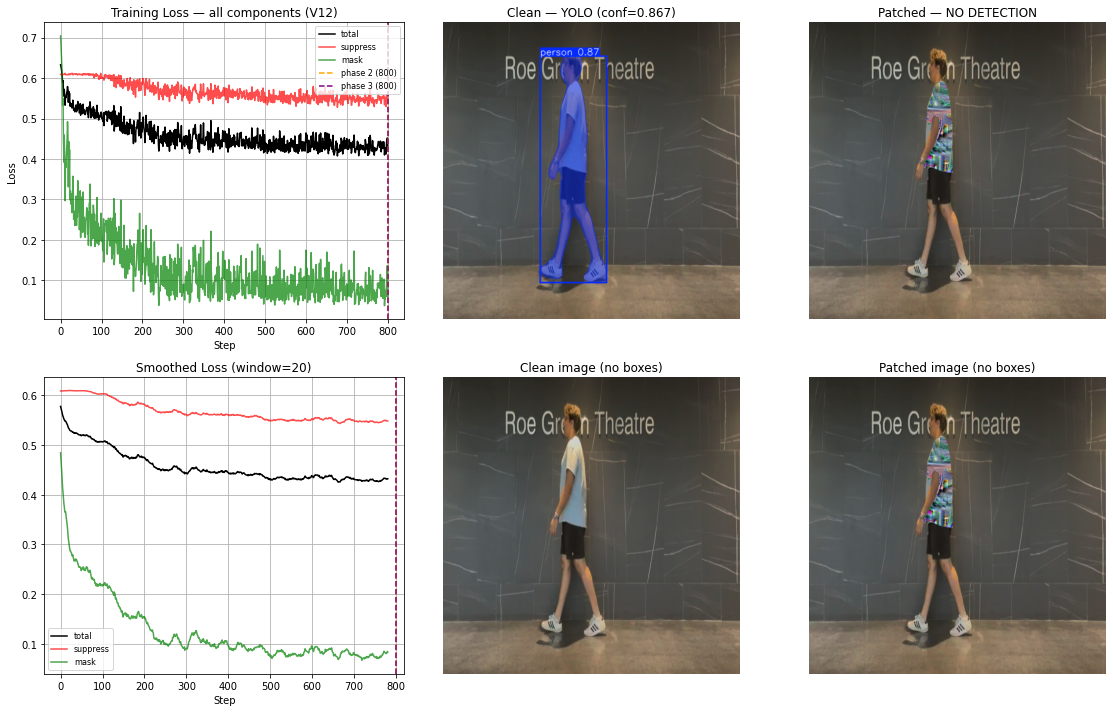

In [13]:
# Cell 13 — Visual evaluation + loss component breakdown
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Row 1: loss curves
axes[0, 0].plot(loss_history,     label='total',    color='black')
axes[0, 0].plot(suppress_history, label='suppress', color='red',   alpha=0.7)
axes[0, 0].plot(mask_history,     label='mask',     color='green', alpha=0.7)
if CURRICULUM_STEPS > 0:
    axes[0, 0].axvline(x=CURRICULUM_STEPS, color='orange', linestyle='--',
                       label=f'phase 2 ({CURRICULUM_STEPS})')
axes[0, 0].axvline(x=800, color='purple', linestyle='--', label='phase 3 (800)')
axes[0, 0].set_title('Training Loss — all components (V12)')
axes[0, 0].set_xlabel('Step')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True)

# Row 1: clean detection
axes[0, 1].imshow(cv2.cvtColor(results_clean_eval[0].plot(), cv2.COLOR_BGR2RGB))
axes[0, 1].set_title(f'Clean — YOLO (conf={yolo_clean:.3f})')
axes[0, 1].axis('off')

# Row 1: patched detection
patched_label = f'Patched — YOLO (conf={yolo_patched:.3f})' if yolo_patched else 'Patched — NO DETECTION'
axes[0, 2].imshow(cv2.cvtColor(results_patched_eval[0].plot(), cv2.COLOR_BGR2RGB))
axes[0, 2].set_title(patched_label)
axes[0, 2].axis('off')

# Row 2: smoothed loss (window=20)
window = 20
def smooth(x):
    return np.convolve(x, np.ones(window)/window, mode='valid')

axes[1, 0].plot(smooth(loss_history),     color='black', label='total')
axes[1, 0].plot(smooth(suppress_history), color='red',   label='suppress', alpha=0.7)
axes[1, 0].plot(smooth(mask_history),     color='green', label='mask',     alpha=0.7)
if CURRICULUM_STEPS > 0:
    axes[1, 0].axvline(x=CURRICULUM_STEPS, color='orange', linestyle='--')
axes[1, 0].axvline(x=800, color='purple', linestyle='--')
axes[1, 0].set_title(f'Smoothed Loss (window={window})')
axes[1, 0].set_xlabel('Step')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True)

# Row 2: clean image (no overlay)
axes[1, 1].imshow(cv2.cvtColor(img_eval_640, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title('Clean image (no boxes)')
axes[1, 1].axis('off')

# Row 2: patched image (no overlay)
axes[1, 2].imshow(cv2.cvtColor(img_patched_np, cv2.COLOR_BGR2RGB))
axes[1, 2].set_title('Patched image (no boxes)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()


In [14]:
patch_np = patch.detach().cpu().squeeze().permute(1, 2, 0).numpy()
patch_np = (patch_np * 255).astype(np.uint8)
patch_bgr = cv2.cvtColor(patch_np, cv2.COLOR_RGB2BGR)

save_path = f"patch.png"
cv2.imwrite(save_path, patch_bgr)
print(f"Patch saved to {save_path}")

Patch saved to patch.png


In [ ]:
# Cell 14 — Video evaluation: per-frame suppression rate + overlaid video export
from pathlib import Path

def best_person_conf(results):
    boxes = results[0].boxes
    if boxes is None or len(boxes) == 0:
        return None
    m = (boxes.cls == 0)
    return boxes.conf[m].max().item() if m.any() else None

import cv2
import numpy as np

eval_video_path = EVAL_VIDEO
output_dir = Path('../output')
output_dir.mkdir(parents=True, exist_ok=True)
output_video_path = str(output_dir / 'patch_v13_eval.mp4')

# Load SegFormer once — avoids reloading model for every frame
seg_processor, seg_model_inst, seg_device = load_segformer_model(device=DEVICE)

cap = cv2.VideoCapture(eval_video_path)
if not cap.isOpened():
    raise RuntimeError(f'Cannot open eval video: {eval_video_path}')

fps = cap.get(cv2.CAP_PROP_FPS)
w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

writer = cv2.VideoWriter(
    output_video_path,
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (w, h)
)

patch_np = patch.detach().cpu().squeeze().permute(1, 2, 0).numpy()
patch_np = (patch_np * 255).astype(np.uint8)
patch_bgr = cv2.cvtColor(patch_np, cv2.COLOR_RGB2BGR)

frame_idx      = 0
clean_confs    = []
patched_confs  = []
suppressed     = 0
empty_mask     = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Segmentation mask for this frame
    mask = get_single_mask_from_image(
        frame,
        processor=seg_processor,
        model=seg_model_inst,
        device=seg_device
    )

    # YOLO on clean frame
    clean_result = yolo(cv2.resize(frame, (640, 640)), verbose=False)
    c_conf = best_person_conf(clean_result)
    clean_confs.append(c_conf or 0.0)

    # If mask is empty, skip patching for this frame
    if not mask.any():
        empty_mask += 1
        writer.write(frame)
        frame_idx += 1
        continue

    # Apply patch using segmentation mask
    patched_frame = overlay_patch_on_image(frame, mask, patch_bgr)

    # YOLO on patched frame
    patched_result = yolo(cv2.resize(patched_frame, (640, 640)), verbose=False)
    p_conf = best_person_conf(patched_result)
    patched_confs.append(p_conf or 0.0)

    if p_conf is None or p_conf < 0.5:
        suppressed += 1

    writer.write(patched_frame)
    frame_idx += 1

cap.release()
writer.release()

# ── Summary ─────────────────────────────────────────────────────
total          = frame_idx
patched_frames = total - empty_mask
clean_det      = sum(1 for c in clean_confs if c >= 0.5)
patched_det    = patched_frames - suppressed

print('═' * 50)
print('  VIDEO EVALUATION SUMMARY')
print('─' * 50)
print(f'  Eval video:          {Path(eval_video_path).name}')
print(f'  Frames evaluated:    {total}')
print(f'  Frames w/ mask:      {patched_frames}  (empty mask: {empty_mask})')
print(f'  Clean detected:      {clean_det}  ({100*clean_det/max(total,1):.1f}%)')
print(f'  Patched detected:    {patched_det}  ({100*patched_det/max(patched_frames,1):.1f}%)')
print(f'  Suppression rate:    {100*suppressed/max(patched_frames,1):.1f}%')
print(f'  Avg clean conf:      {np.mean(clean_confs):.3f}')
if patched_confs:
    det_confs = [c for c in patched_confs if c > 0]
    avg_p = np.mean(det_confs) if det_confs else 0.0
    print(f'  Avg patched conf:    {avg_p:.3f}  (detected frames only)')
print('─' * 50)
print(f'  Output video:        {output_video_path}')
print('═' * 50)